# MDN Confusion Noise Emulator — Exploration

Load the trained MDN and generated training data, then visualise:
1. Training data distributions (S_conf, N_res vs hyperparameters)
2. Training loss curves
3. MDN predictions vs truth (scatter + residuals)
4. Conditional density slices (mixture components)
5. Calibration check

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

# Path to saved artefacts (adjust if you moved them)
MODEL_DIR = "./trained_models"

# Load training data
data = np.load(f"{MODEL_DIR}/training_data.npz")
X = data["X"]                    # (N, 4): [log10(N_tot), alpha, beta, f_center]
Y = data["Y"]                    # (N,): log(S_conf) — 1D target
N_res = data["N_res"]            # (N,): resolved counts (for validation)
resolved_flag = data["resolved_flag"]  # (N,): 1.0 if fully resolved
X_train = data["X_train"]
Y_train = data["Y_train"]
N_res_train = data["N_res_train"]
rf_train = data["resolved_flag_train"]
X_val = data["X_val"]
Y_val = data["Y_val"]
N_res_val = data["N_res_val"]
rf_val = data["resolved_flag_val"]
band_edges = data["band_edges"]

# Load MDN model
with open(f"{MODEL_DIR}/mdn_model.pkl", "rb") as f:
    model = pickle.load(f)

params = model["params"]
X_mean = model["X_mean"]
X_std = model["X_std"]
history = model["history"]
config = model["config"]

print(f"Training samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}")
print(f"Input dim: {X.shape[1]}, Target: 1D (log S_conf)")
print(f"Fully resolved: {int(resolved_flag.sum())} / {len(resolved_flag)} ({resolved_flag.mean():.1%})")
print(f"Config: {config}")

## 1. Training Data Distributions

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Input distributions (X[:, 0] is log10(N_tot) now)
labels_x = [r"$\log_{10}(N_\mathrm{tot})$", r"$\alpha$", r"$\beta$"]
for i, (ax, lbl) in enumerate(zip(axes[0, :3], labels_x)):
    ax.hist(X[:, i], bins=50, alpha=0.7, edgecolor="k", linewidth=0.3)
    ax.set_xlabel(lbl)
    ax.set_ylabel("Count")

# Output distributions (Y is 1D now)
not_resolved = resolved_flag < 0.5
axes[1, 0].hist(Y[not_resolved], bins=50, alpha=0.7, color="C1", edgecolor="k", linewidth=0.3)
axes[1, 0].set_xlabel(r"$\log(S_\mathrm{conf})$")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Non-resolved only")

axes[1, 1].hist(N_res[not_resolved], bins=50, alpha=0.7, color="C2", edgecolor="k", linewidth=0.3)
axes[1, 1].set_xlabel(r"$N_\mathrm{res}$")
axes[1, 1].set_ylabel("Count")

# S_conf vs log10(N_tot) coloured by band
sc = axes[1, 2].scatter(X[not_resolved, 0], Y[not_resolved],
                         c=X[not_resolved, 3], s=1, alpha=0.3, cmap="viridis")
axes[1, 2].set_xlabel(r"$\log_{10}(N_\mathrm{tot})$")
axes[1, 2].set_ylabel(r"$\log(S_\mathrm{conf})$")
plt.colorbar(sc, ax=axes[1, 2], label=r"$f_\mathrm{center}$ [Hz]")

fig.suptitle("Training Data Distributions", fontsize=14)
fig.tight_layout()
plt.show()

## 2. Training Loss Curves

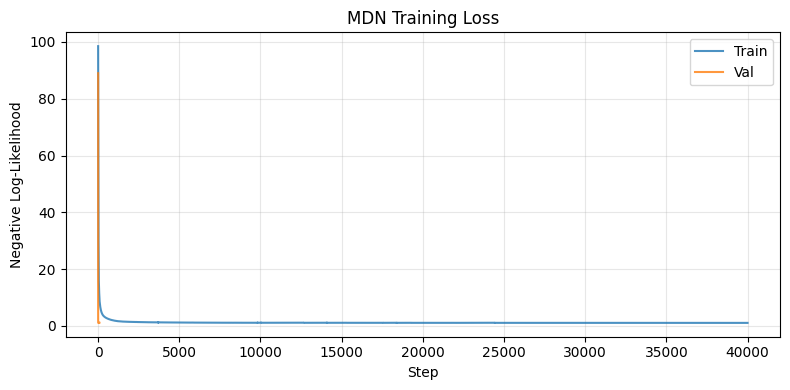

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))

if "train_loss" in history:
    ax.plot(history["train_loss"], label="Train", alpha=0.8)
if "val_loss" in history:
    ax.plot(history["val_loss"], label="Val", alpha=0.8)

ax.set_xlabel("Step")
ax.set_ylabel("Negative Log-Likelihood")
ax.set_title("MDN Training Loss")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 3. MDN Predictions vs Truth

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath("../.." if os.path.basename(os.getcwd()) == "noise_emulator" else "."))

from tophat_populations.noise_emulator.network import (
    gated_mdn_forward, gated_mdn_predict_mean, gated_mdn_predict_variance,
    gated_mdn_predict_resolved_prob, compute_lambda_res,
)
import jax

n_components = config["n_components"]

# Normalise validation inputs
X_val_jax = jnp.array(X_val)
Y_val_jax = jnp.array(Y_val)          # 1D: log S_conf
Nres_val_jax = jnp.array(N_res_val)   # for validation
rf_val_jax = jnp.array(rf_val)
X_val_norm = (X_val_jax - jnp.array(X_mean)) / jnp.array(X_std)

# Gate predictions
pred_resolved_prob = gated_mdn_predict_resolved_prob(params, X_val_norm, n_components=n_components)
pred_resolved = pred_resolved_prob > 0.5
gate_accuracy = float(jnp.mean(pred_resolved == (rf_val_jax > 0.5)))
n_val_resolved = int(jnp.sum(rf_val_jax > 0.5))
print(f"Gate accuracy: {gate_accuracy:.2%}  ({n_val_resolved} / {len(rf_val_jax)} val bands fully resolved)")

# MDN predictions on non-resolved rows only
not_resolved_mask = rf_val_jax < 0.5
X_val_nr = X_val_norm[not_resolved_mask]
Y_val_nr = Y_val_jax[not_resolved_mask]          # 1D: log S_conf
Nres_val_nr = Nres_val_jax[not_resolved_mask]
X_val_nr_raw = X_val_jax[not_resolved_mask]

# MDN predicts log S_conf (scalar per sample)
pred_mean = gated_mdn_predict_mean(params, X_val_nr, n_components=n_components)    # (...,)
pred_var = gated_mdn_predict_variance(params, X_val_nr, n_components=n_components)  # (...,)
pred_std = jnp.sqrt(pred_var)

# Analytic Poisson rate from predicted log S_conf
delta_f_band = config.get("delta_f_band", band_edges[1] - band_edges[0])
f_min_cfg = config["f_min"]
f_max_cfg = config["f_max"]
T_obs = config.get("T_obs", 3.15e7)
A_min = config.get("A_min", 1e-3)
A_max = config.get("A_max", 10.0)
S_instr = config.get("S_instr", 1.1234)
rho_th = config.get("rho_th", 5.0)

pred_lambda_res = jax.vmap(
    lambda log_s, x: compute_lambda_res(
        log_s, 10**x[0], x[1], x[2], x[3],
        S_instr, T_obs, rho_th, A_min, A_max,
        delta_f_band, f_min_cfg, f_max_cfg
    )
)(pred_mean, X_val_nr_raw)

# Coloring
log10_n_tot_vals = np.array(X_val_nr_raw[:, 0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: log S_conf (MDN prediction)
truth_s = np.array(Y_val_nr)
pred_s = np.array(pred_mean)
err_s = np.array(pred_std)

ax = axes[0]
ax.errorbar(truth_s, pred_s, yerr=err_s, fmt="none", elinewidth=0.3, ecolor="0.7", alpha=0.3, zorder=1)
sc = ax.scatter(truth_s, pred_s, c=log10_n_tot_vals, s=4, alpha=0.4, cmap="viridis", zorder=2)
lims = [min(truth_s.min(), pred_s.min()), max(truth_s.max(), pred_s.max())]
ax.plot(lims, lims, "r--", lw=1, label="y=x", zorder=3)
ax.set_xlabel(r"True $\log(S_\mathrm{conf})$")
ax.set_ylabel(r"Predicted $\log(S_\mathrm{conf})$")
ax.set_title(r"$\log(S_\mathrm{conf})$ — MDN prediction")
ax.legend()
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label=r"$\log_{10}(N_\mathrm{tot})$")

# Panel 2: N_res (analytic Poisson rate from predicted S_conf)
truth_n = np.array(Nres_val_nr)
pred_n = np.array(pred_lambda_res)

ax = axes[1]
sc2 = ax.scatter(truth_n, pred_n, c=log10_n_tot_vals, s=4, alpha=0.4, cmap="viridis", zorder=2)
lims_n = [min(truth_n.min(), pred_n.min()), max(truth_n.max(), pred_n.max())]
ax.plot(lims_n, lims_n, "r--", lw=1, label="y=x", zorder=3)
ax.set_xlabel(r"True $N_\mathrm{res}$")
ax.set_ylabel(r"Analytic $\lambda_\mathrm{res}$")
ax.set_title(r"$N_\mathrm{res}$ — analytic from predicted $S_\mathrm{conf}$")
ax.legend()
ax.grid(True, alpha=0.3)
plt.colorbar(sc2, ax=ax, label=r"$\log_{10}(N_\mathrm{tot})$")

fig.suptitle("Gated MDN Predictions vs Truth (non-resolved validation bands)", fontsize=14)
fig.tight_layout()
plt.show()

## 4. Residual Distributions

In [ ]:
residuals = np.array(Y_val_nr - pred_mean)
normalised_res = np.array((Y_val_nr - pred_mean) / pred_std)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw residuals
axes[0].hist(residuals, bins=60, alpha=0.7, edgecolor="k", linewidth=0.3)
axes[0].set_xlabel(r"Residual ($\log S_\mathrm{conf}$)")
axes[0].set_title(r"Raw Residuals — $\log(S_\mathrm{conf})$")
axes[0].axvline(0, color="r", ls="--")

# Normalised residuals
axes[1].hist(normalised_res, bins=60, alpha=0.7, color="C1", edgecolor="k", linewidth=0.3, density=True)
z = np.linspace(-4, 4, 200)
axes[1].plot(z, np.exp(-z**2/2) / np.sqrt(2*np.pi), "r-", lw=1.5, label=r"$\mathcal{N}(0,1)$")
axes[1].set_xlabel(r"Normalised Residual ($\log S_\mathrm{conf}$)")
axes[1].set_title(r"Normalised Residuals — $\log(S_\mathrm{conf})$")
axes[1].legend()

fig.suptitle("Residuals (non-resolved validation bands only)", fontsize=14)
fig.tight_layout()
plt.show()

## 5. Conditional Density Slices

Fix two hyperparameters at their fiducial values and sweep the third, showing the MDN mixture density for each band.

In [ ]:
from tophat_populations.noise_emulator.network import gated_mdn_forward

# Sweep N_tot at fiducial alpha=4, beta=500, for band 0 and band 5
n_tot_values = np.linspace(3000, 30000, 50)
log10_n_tot_values = np.log10(n_tot_values)
fiducial_alpha = 4.0
fiducial_beta = 500.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, band_idx in zip(axes, [0, 5]):
    band_centre = 0.5 * (band_edges[band_idx] + band_edges[band_idx + 1])
    
    # Build inputs with log10(N_tot) as first feature
    inputs = np.column_stack([
        log10_n_tot_values,
        np.full_like(n_tot_values, fiducial_alpha),
        np.full_like(n_tot_values, fiducial_beta),
        np.full_like(n_tot_values, band_centre),
    ])
    x_norm = (jnp.array(inputs) - jnp.array(X_mean)) / jnp.array(X_std)
    
    # predict_mean and predict_variance now return scalars (...,)
    means = gated_mdn_predict_mean(params, x_norm, n_components=n_components)
    stds = jnp.sqrt(gated_mdn_predict_variance(params, x_norm, n_components=n_components))
    p_resolved = gated_mdn_predict_resolved_prob(params, x_norm, n_components=n_components)
    
    # Plot mean +/- 1,2 sigma for log S_conf
    m = np.array(means)
    s = np.array(stds)
    ax.fill_between(n_tot_values, m - 2*s, m + 2*s, alpha=0.2, color="C0", label=r"$\pm 2\sigma$")
    ax.fill_between(n_tot_values, m - s, m + s, alpha=0.4, color="C0", label=r"$\pm 1\sigma$")
    ax.plot(n_tot_values, m, "C0-", lw=2, label="Mean")
    
    # Overlay validation data for this band (non-resolved only)
    mask = np.isclose(X_val[:, 3], band_centre, atol=1e-6) & (rf_val < 0.5)
    ax.scatter(10**X_val[mask, 0], Y_val[mask], s=5, alpha=0.3, color="C1", label="Val data")
    
    # Show P(resolved) on twin axis
    ax2 = ax.twinx()
    ax2.plot(n_tot_values, np.array(p_resolved), "C3--", lw=1.5, alpha=0.7)
    ax2.set_ylabel(r"$P(\mathrm{fully\ resolved})$", color="C3")
    ax2.set_ylim(-0.05, 1.05)
    ax2.tick_params(axis="y", labelcolor="C3")
    
    ax.set_xlabel(r"$N_\mathrm{tot}$")
    ax.set_ylabel(r"$\log(S_\mathrm{conf})$")
    ax.set_title(f"Band {band_idx} (f ~ {band_centre:.1e} Hz)")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)

fig.suptitle(r"Conditional: $\alpha=4$, $\beta=500$, sweep $N_\mathrm{tot}$", fontsize=14)
fig.tight_layout()
plt.show()

## 6. Calibration Check

Fraction of validation points within $k\sigma$ for $k = 1, 2, 3$. A well-calibrated MDN should match 68%, 95%, 99.7%.

In [ ]:
from scipy import stats

abs_norm_res = np.abs(normalised_res)
expected = [stats.norm.cdf(k) - stats.norm.cdf(-k) for k in [1, 2, 3]]

print("Calibration check (non-resolved bands only)")
print(f"{'':>25s}  {'log S_conf':>12s}  {'Expected':>10s}")
print("-" * 55)
for k, exp in zip([1, 2, 3], expected):
    frac_s = np.mean(abs_norm_res < k)
    print(f"  Within {k}-sigma:          {frac_s:>11.1%}  {exp:>9.1%}")